In [238]:
import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [239]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 16

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([16, 1024])


seed :  107
torch.Size([512, 33])
[[ -4.53419      0.03369892  10.504549     1.813822    -7.876463
    5.202613    -7.861482    -2.9722478    4.694421   -13.50445
    2.6566415    3.5103161   -3.315248    -4.2336755   -8.373724
    1.7325884 ]]


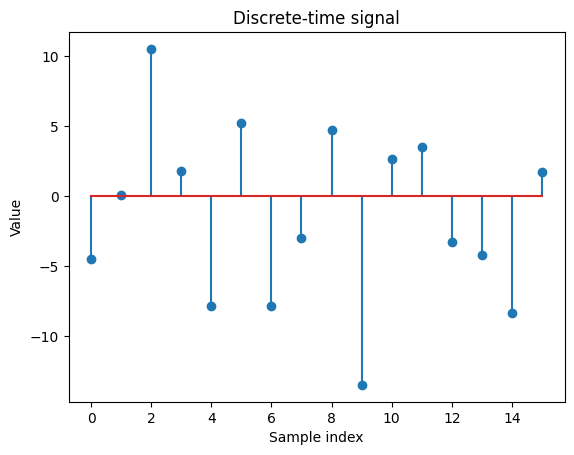

(512, 33)


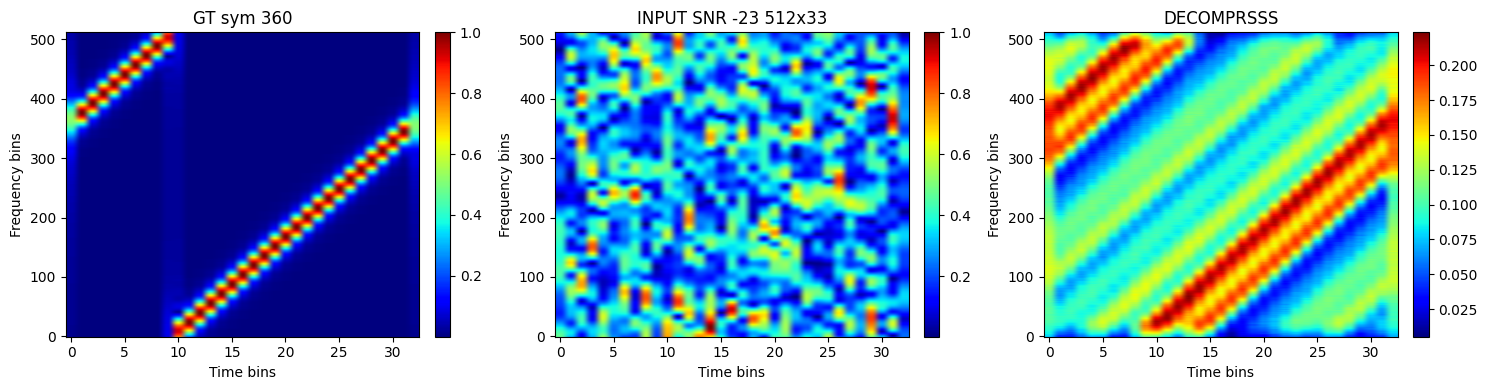

RMSE :  0.26515899837822154
RMPE :  0.07030929442094169
RMSE - to signal max ratio = 118.594 %
RMSE - to signal mean ratio = 237.102 %
Error Vector Magnitude = 0.737 => 73.746 %
RMSE :  0.1856124835179777
RMPE :  0.03445199403771155
RMSE - to signal max ratio = 83.016 %
RMSE - to signal mean ratio = 165.973 %
Error Vector Magnitude = 0.852 => 85.206 %


np.float64(0.1856124835179777)

In [240]:
symbol1 = 360
# EXAMPLE OF COMPRESS and DECOMPRESS
random_ = np.random.randint(1, 999)  # integer from 1 to 10 (inclusive)
print("seed : ",random_)
seed = random_
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = -23
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam.compress(flat)
print(out1)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()

out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([16, 1024])
torch.Size([512, 33])


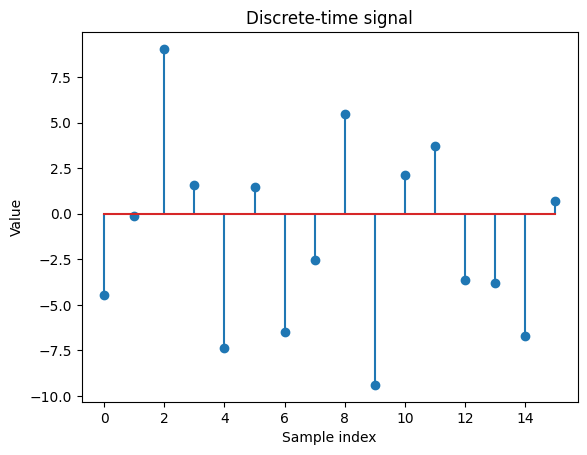

(512, 33)


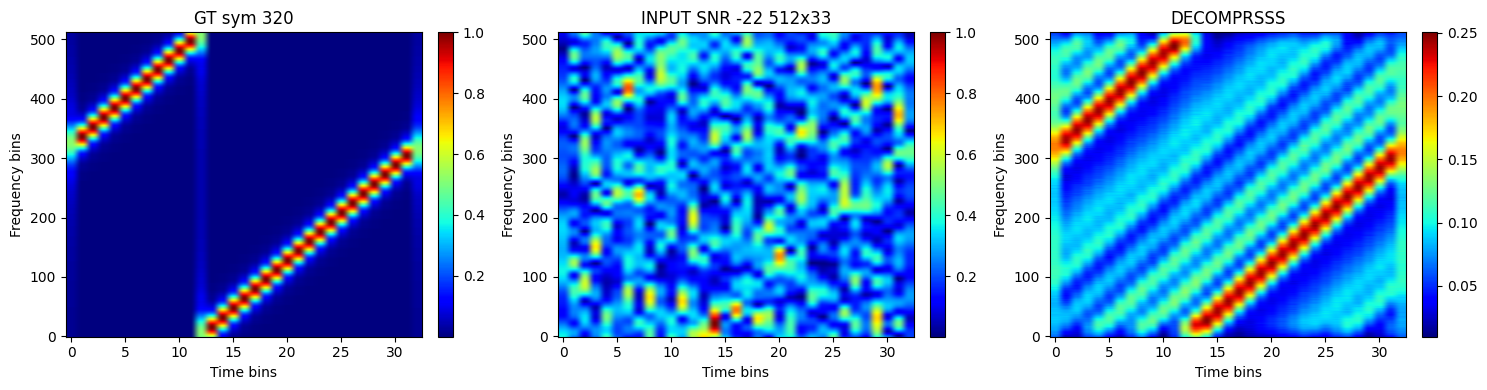

RMSE :  0.21365164451285845
RMPE :  0.045647025203048835
RMSE - to signal max ratio = 85.324 %
RMSE - to signal mean ratio = 235.287 %
Error Vector Magnitude = 0.733 => 73.317 %
RMSE :  0.16979538713147152
RMPE :  0.028830473491126288
RMSE - to signal max ratio = 67.810 %
RMSE - to signal mean ratio = 186.990 %
Error Vector Magnitude = 0.780 => 77.971 %


np.float64(0.16979538713147152)

In [241]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 16

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam2 = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam2.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


symbol1 = 320
# EXAMPLE OF COMPRESS and DECOMPRESS
seed = seed
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = -22
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam2.compress(flat)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()
out2 = multi_bam2.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

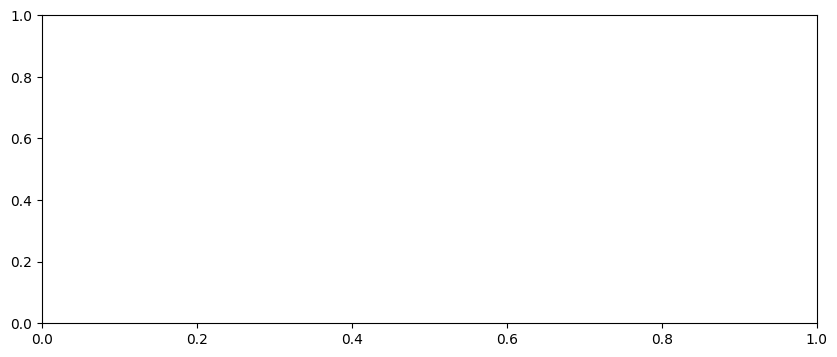

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
# -------------------------------
# PARAMETERS
# -------------------------------
sf = sf
bw = bw
fs = fs
input_row = input_row
input_col = input_col

snr = -15
seed = 591

plt.ion()  # interactive mode ON
fig, ax = plt.subplots(figsize=(10, 4))

# -------------------------------
# LOOP OVER SYMBOLS
# -------------------------------
active = False
if active:
        
    for symbol in range(0, 512):
        clear_output(wait=True)
        # 1. Generate clean symbol
        x1 = lora_init.gen_symbol_fs(symbol, sf=sf, bw=bw, Fs=fs)

        # 2. Add noise (fixed seed for reproducibility)
        x = lora_init.awgn_iq_with_seed(x1, snr, seed)

        # 3. Spectrogram
        input_spec = create_spectrogram_from_torch(
            x, sf, bw, fs,
            input_row, input_col,
            0, 0, 1, None
        )

        # 4. Flatten before compress
        flat = input_spec.flatten().reshape(1, -1)

        # 5. Compress
        out = multi_bam.compress(flat)
        a = out.squeeze()

        # -------------------------------
        # PLOTTING (movie style)
        # -------------------------------
        plt.figure(figsize=(10,4))
        plt.bar(np.arange(len(a)), a)
        plt.ylim(-15, 15)
        plt.yticks(np.arange(-15, 15, 1)) 
        plt.title(f"Compressed Representation | Symbol = {symbol}")
        plt.xlabel("Latent Dimension")
        plt.ylabel("Value")
        plt.show()

    plt.ioff()  # interactive mode OFF
